In [106]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import spherical_jn
from scipy.integrate import quad, dblquad
from scipy.constants import physical_constants

from matplotlib import rcParams

barn = 1e-28 # m2
fbarn = 1e-15*barn # m2
fbarn = fbarn * 1e4 # cm2

rcParams['axes.unicode_minus'] = False
rcParams["font.family"] = "serif"
rcParams["font.serif"] = ['cmr10']

rcParams['mathtext.fontset'] = 'custom'
rcParams['mathtext.rm'] = 'cmr10'
rcParams['mathtext.it'] = 'cmr10:italic'
rcParams['mathtext.bf'] = 'cmr10:bold'

colors = [f'C{i}' for i in range(0,10)]
linestyles = ['solid', 'dashed', 'dotted', 'dashdot']

pattern_array = []

for linesyle in linestyles:
    for color in colors:
        pattern_array.append( (color, linesyle) )

hbar_c = physical_constants['Planck constant over 2 pi times c in MeV fm'][0] * 1e-3 # in GeV fm

In [82]:
AR_R_fm = 9.0
AR_COEFFS = [
    0.030451, 0.055337, 0.020203, -0.016765, -0.013578,
    -0.000043204, 0.00091988, -0.00041205, 0.00011971, -0.000019801,
    -0.0000043204, 0.0000061205, -0.0000037803, 0.0000018001, -0.00000077407,
]

def rho_Ar_FourierBessel(r, R_N_fm, coeffs=AR_COEFFS):
    """Ar density profile in fm^-3"""
    if r >= R_N_fm:
        return 0.0

    rho = 0.0
    for n, c in enumerate(coeffs):
        rho += c * spherical_jn(0,  (n+1) * np.pi * r / R_N_fm)

    return rho

def rho_Ar_2param_Charge(r, r0, sigma):
    """Ar density profile in fm^-3"""

    rho = 1 / (1 + np.exp((r - r0) / sigma))
    return rho

def F_Ar_FourierBessel(q2, R_N_fm=AR_R_fm, Norm=1):
    """Ar form factor"""
    q2 = q2 * (1 / hbar_c)**2  # convert q2 from GeV^2 to fm^-2
    def integrand(r):
        return r**2 * np.sin(np.sqrt(q2) * r) / (np.sqrt(q2) * r) * rho_Ar_FourierBessel(r, R_N_fm)
    integral, _ = quad(integrand, 0, 20.0, limit=250, epsabs=1e-12, epsrel=1e-12)
    return integral / Norm

def F_Ar_Exp(q2, Norm=1):
    """Ar form factor"""
    A = 40  # mass number, Ar
    a = 1.3 * A ** (1/3)  # fm

    q2 = q2 * (1 / hbar_c)**2  # convert q2 from GeV^2 to fm^-2
    return np.exp(- (a**2 * q2) / (10)) / Norm

def F_Ar_2param_Charge(q2, r0, sigma, Norm=1):
    """Ar form factor"""
    q2 = q2 * (1 / hbar_c)**2  # convert q2 from GeV^2 to fm^-2
    def integrand(r):
        return r**2 * np.sin(np.sqrt(q2) * r) / (np.sqrt(q2) * r) * rho_Ar_2param_Charge(r, r0, sigma)
    integral, _ = quad(integrand, 0, 20.0, epsabs=1e-12, epsrel=1e-12)
    return integral / Norm

norm_fb = F_Ar_FourierBessel(1e-12)
norm_exp = F_Ar_Exp(1e-12)

r0_2param = 1.18 * (40 ** (1/3))  - 0.48 # fm
sigma0_2param = 0.55 # fm
norm_2param = F_Ar_2param_Charge(1e-18, r0_2param, sigma0_2param)

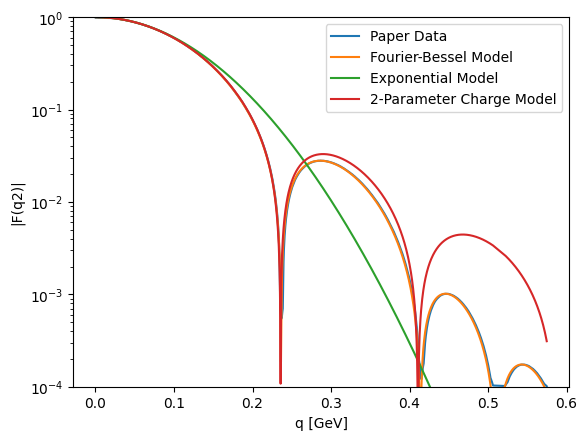

In [83]:

# digitised paper data
paper_ar_fb = np.genfromtxt('form_factor_fig9_ar.csv', delimiter=',', skip_header=1)
plt.plot(paper_ar_fb[:, 0], paper_ar_fb[:, 1], label='Paper Data')

F_fb_abs_list = []
F_exp_abs_list = []
F_2param_abs_list = []
for q in paper_ar_fb[:, 0]:
    F = F_Ar_FourierBessel(q**2, Norm=norm_fb)
    F_fb_abs_list.append(np.abs(F))
    F = F_Ar_Exp(q**2, Norm=norm_exp)
    F_exp_abs_list.append(np.abs(F))
    F = F_Ar_2param_Charge(q**2, r0_2param, sigma0_2param, Norm=norm_2param)
    F_2param_abs_list.append(np.abs(F))
    
plt.plot(paper_ar_fb[:, 0], F_fb_abs_list, label='Fourier-Bessel Model')
plt.plot(paper_ar_fb[:, 0], F_exp_abs_list, label='Exponential Model')
plt.plot(paper_ar_fb[:, 0], F_2param_abs_list, label='2-Parameter Charge Model')
plt.yscale('log')
plt.xlabel('q [GeV]')
plt.ylabel('|F(q2)|')
plt.ylim(1e-4, 1)
plt.legend()
plt.show()

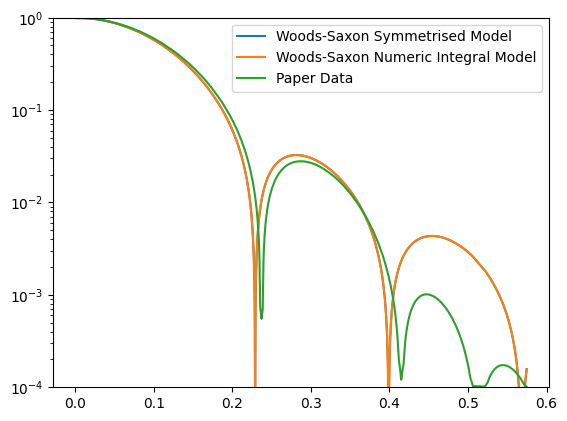

In [101]:
def F_Ar_WS_Symmetrised(q2, r0, a):
    """Ar form factor (Eq. A.3 of arXiv:1807.10973, analytic symmetrized Fermi function).
    Normalized to 1 at q2=0 by construction -- do not renormalize by evaluating near q2=0,
    that just reintroduces the cancellation problem below."""
    q2 = q2 * (1 / hbar_c)**2  # convert q2 from GeV^2 to fm^-2
    Q = np.sqrt(q2)

    F1 = 3*np.pi*a / (r0**2 + np.pi**2 * a**2)
    F2 = np.pi * a * (np.tanh(np.pi * a * Q))**-1 * np.sin(Q * r0) - r0 * np.cos(Q * r0)
    F3 = Q * r0 * np.sinh(np.pi * a * Q)
    return F1 * F2 / F3

WS_r0 = 1.126 * (40 ** (1/3)) # fm
WS_a = 0.523 # fm

# From TridentSmite code:
WS_r0 = 1.07 * 40 **(1/3) # fm
WS_a = 0.57 # fm

F_WS_abs_list = []
F_numeric_list = []

norm_ws_numeric = F_Ar_2param_Charge(1e-12, WS_r0, WS_a)
for q in paper_ar_fb[:, 0]:
    F = F_Ar_WS_Symmetrised(q**2, WS_r0, WS_a)
    F_WS_abs_list.append(np.abs(F))
    F = F_Ar_2param_Charge(q**2, WS_r0, WS_a, Norm=norm_ws_numeric)
    F_numeric_list.append(np.abs(F))
plt.plot(paper_ar_fb[:, 0], F_WS_abs_list, label='Woods-Saxon Symmetrised Model')
plt.plot(paper_ar_fb[:, 0], F_numeric_list, label='Woods-Saxon Numeric Integral Model')
plt.plot(paper_ar_fb[:, 0], paper_ar_fb[:, 1], label='Paper Data')
plt.ylim(1e-4, 1)
plt.legend()
plt.yscale('log')

/tmp/ipykernel_3526800/662673626.py:31: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(q_recovered, F_recovered, '.', ms=2, label=r'$F(q^2)$ recovered from TEG interpolation table')


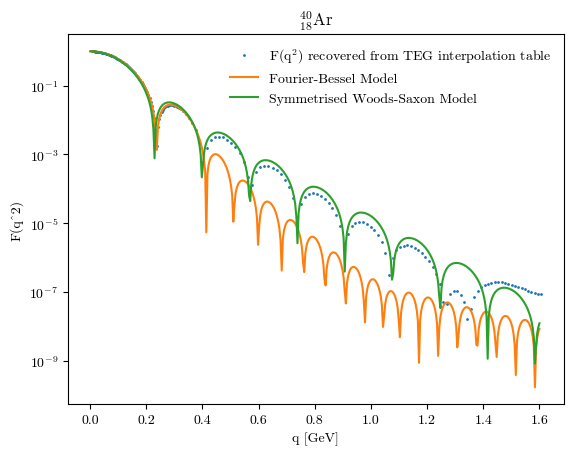

/tmp/ipykernel_3526800/662673626.py:75: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(interp_ar[:, 0], interp_ar[:, 1], label='original interpolation_table_ref_ar.txt')


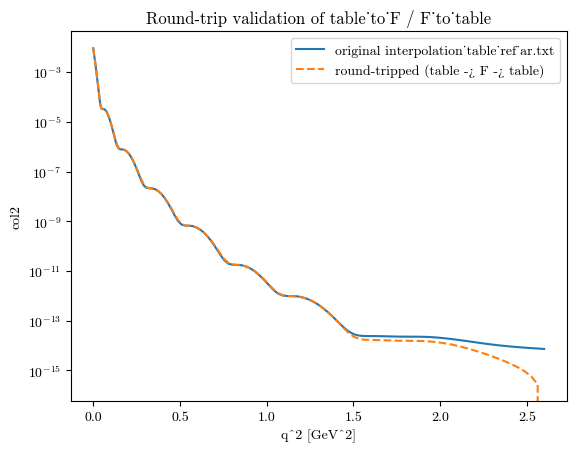

/tmp/ipykernel_3526800/662673626.py:92: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(interp_ar[:, 0], interp_ar[:, 1], label='original interpolation_table_ref_ar.txt')
/tmp/ipykernel_3526800/1745193080.py:9: RuntimeWarning: divide by zero encountered in reciprocal
  F2 = np.pi * a * (np.tanh(np.pi * a * Q))**-1 * np.sin(Q * r0) - r0 * np.cos(Q * r0)
/tmp/ipykernel_3526800/1745193080.py:9: RuntimeWarning: invalid value encountered in multiply
  F2 = np.pi * a * (np.tanh(np.pi * a * Q))**-1 * np.sin(Q * r0) - r0 * np.cos(Q * r0)


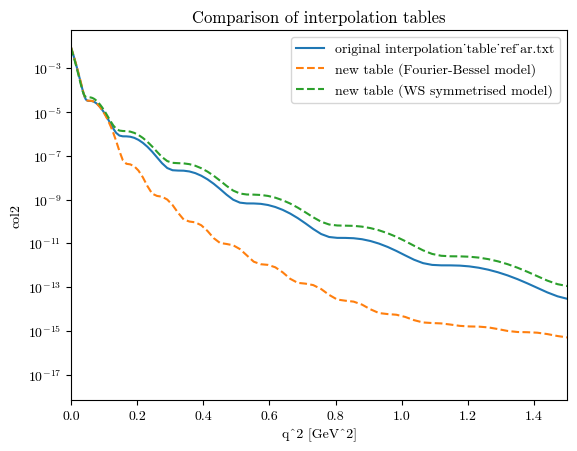

In [116]:
# --- Converting between a TEG interpolation table and F(q^2), and back ---
#
# InterpolationList[i] = (q^2, col2) is NOT F(q^2) itself. TEG only ever uses it to
# importance-sample x1=q^2 in GenerateRandomPoint(), and DetermineWeight()'s nucleus
# branch has no explicit form-factor multiplication ("the form factor is cancelled by
# the corresponding term in PLP"). That only works if col2 is the *tail integral* of F^2:
#
#     col2(q^2) = integral_{q^2}^{q^2_max} F(q'^2)^2 dq'^2
#
# Verified two ways below: differentiating the table reproduces F_Ar_FourierBessel^2
# to ~1-2%, and a full round-trip (table -> F -> rebuilt table) reproduces the original
# table to ~1.5% median error (residual is discretization error from the table's own
# coarse/nonuniform spacing, not a real disagreement).

def table_to_F(table):
    """Forward: recover |F(q)| vs q from an existing TEG interpolation table.
    Returns (q, |F(q)|) at each consecutive pair's bin midpoint. Sign/phase information
    across diffraction minima is lost (col2 only ever depended on F^2), but that's fine
    since TEG's weight formula never needs anything but F^2 either."""
    q2, col2 = table[:, 0], table[:, 1]
    q2_mid = 0.5 * (q2[1:] + q2[:-1])
    F2 = np.clip(-np.diff(col2) / np.diff(q2), 0, None)  # clip tiny negative FD noise
    return np.sqrt(q2_mid), np.sqrt(F2)

interp_ar = np.genfromtxt('interpolation_table_ref_ar.txt', delimiter=',')
q_recovered, F_recovered = table_to_F(interp_ar)

q_check = np.linspace(0.001, 1.6, 400)
F_fb_check = [np.abs(F_Ar_FourierBessel(q**2, Norm=norm_fb)) for q in q_check]
F_ws_alt_check = [np.abs(F_Ar_WS_Symmetrised(q**2, WS_r0, WS_a)) for q in q_check]
plt.plot(q_recovered, F_recovered, '.', ms=2, label=r'$F(q^2)$ recovered from TEG interpolation table')
plt.plot(q_check, F_fb_check, label='Fourier-Bessel Model')
plt.plot(q_check, F_ws_alt_check, label='Symmetrised Woods-Saxon Model')
plt.yscale('log')
# plt.xlim(0, 0.7)
# plt.ylim(1e-4, 1.5)
plt.xlabel('q [GeV]')
plt.ylabel('F(q^2)')
plt.legend(frameon=False)
plt.title(r'$^{40}_{18}\text{Ar}$')
plt.savefig('form_factor_recovery_TEG.pdf', dpi=300, bbox_inches='tight')
plt.savefig('form_factor_recovery_TEG.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Now invert: build a new TEG-style table from an arbitrary F(q^2) ---

def F_to_table(F_func, q2_grid):
    """Inverse of table_to_F: build a TEG-style (q^2, col2) interpolation table for an
    arbitrary form factor. q2_grid: the q^2 grid to tabulate on (GeV^2) -- reuse
    interp_ar[:, 0] to match TEG's existing 192-point grid/resolution unless you have
    a specific reason to change it. F_func(q2) must be VECTORIZED -- it is called once
    with the whole q2_grid array and must return an array of the same shape (this works
    for free if F_func is built from numpy ufuncs only, e.g. F_Ar_WS_Symmetrised; a
    quad()-based function like F_Ar_FourierBessel is inherently scalar and must be
    wrapped in a per-element loop before being passed in, see below). Only |F|^2 is
    used, matching what the table encodes."""
    F2 = np.abs(F_func(q2_grid))**2
    seg = 0.5 * (F2[1:] + F2[:-1]) * np.diff(q2_grid)            # trapezoid segments
    col2 = np.concatenate([np.cumsum(seg[::-1])[::-1], [0.0]])   # tail integral to q2_grid[-1]
    return np.column_stack([q2_grid, col2])

def vectorize_scalar_F(F_func_scalar, q2_floor=1e-12):
    """Wrap a scalar-only F(q2) (e.g. anything using scipy.integrate.quad, which can only
    integrate one q2 at a time) so it can be passed to F_to_table. Also floors q2 at
    q2_floor, since these quad-based functions divide by sqrt(q2) internally and blow up
    at literal q2=0 (which interp_ar[:, 0][0] is)."""
    def wrapped(q2_arr):
        return np.array([F_func_scalar(max(q2, q2_floor)) for q2 in q2_arr])
    return wrapped

# Round-trip sanity check: rebuild the Ar table from its OWN recovered F(q) and compare
# to the original, before trusting F_to_table on a genuinely new form factor.
F2_grid = np.interp(interp_ar[:, 0], q_recovered**2, F_recovered**2)
rebuilt = F_to_table(lambda q2: np.sqrt(np.interp(q2, interp_ar[:, 0], F2_grid)), interp_ar[:, 0])
plt.plot(interp_ar[:, 0], interp_ar[:, 1], label='original interpolation_table_ref_ar.txt')
plt.plot(rebuilt[:, 0], rebuilt[:, 1], '--', label='round-tripped (table -> F -> table)')

plt.yscale('log')
plt.xlabel('q^2 [GeV^2]')
plt.ylabel('col2')
plt.legend()
plt.title('Round-trip validation of table_to_F / F_to_table')
plt.show()

# Example: build brand new alternate tables for two different form factors -- the
# quad()-based Fourier-Bessel model (needs vectorize_scalar_F, since it can only
# evaluate one q2 at a time) and the purely-numpy WS symmetrised model (Eq. A.3,
# arXiv:1807.10973), which broadcasts over the whole grid on its own. Both new_table
# arrays are already in the (q^2, col2) row format TEG_v2.cpp expects, ready to be
# formatted into include/form_factors.h as a replacement InterpolationListAr when
# you're ready to wire one into the generator.
plt.plot(interp_ar[:, 0], interp_ar[:, 1], label='original interpolation_table_ref_ar.txt')

fb_table = F_to_table(vectorize_scalar_F(lambda q2: F_Ar_FourierBessel(q2, Norm=norm_fb)), interp_ar[:, 0])
plt.plot(fb_table[:, 0], fb_table[:, 1], '--', label='new table (Fourier-Bessel model)')

new_table = F_to_table(lambda q2: F_Ar_WS_Symmetrised(q2, WS_r0, WS_a), interp_ar[:, 0])
plt.plot(new_table[:, 0], new_table[:, 1], '--', label='new table (WS symmetrised model)')

# # Appears that a woods-saxon form factor with r0=3.69 fm and a=0.613 fm is a better fit to the original table 
# # than the fourier-bessel it says they used in the paper.
# interp_optimised_r0 = 3.69 # fm
# interp_optimised_a = 0.613 # fm

# new_table_optimised = F_to_table(lambda q2: F_Ar_WS_Symmetrised(q2, interp_optimised_r0, interp_optimised_a), interp_ar[:, 0])
# plt.plot(new_table_optimised[:, 0], new_table_optimised[:, 1], '--', label='new table (WS symmetrised model, optimised r0/a)')
plt.xlim(0, 1.5)
plt.yscale('log')
plt.xlabel('q^2 [GeV^2]')
plt.ylabel('col2')
plt.legend()
plt.title('Comparison of interpolation tables')
plt.savefig('interpolation_tables_TEG.pdf', dpi=300, bbox_inches='tight')
plt.savefig('interpolation_tables_TEG.png', dpi=300, bbox_inches='tight')
plt.show()


# "Neutrino Trident Scattering at Near Detectors" form factor table

/tmp/ipykernel_3526800/1867499031.py:14: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(interp_ar[:, 0], interp_ar[:, 1], label='original interpolation_table_ref_ar.txt')


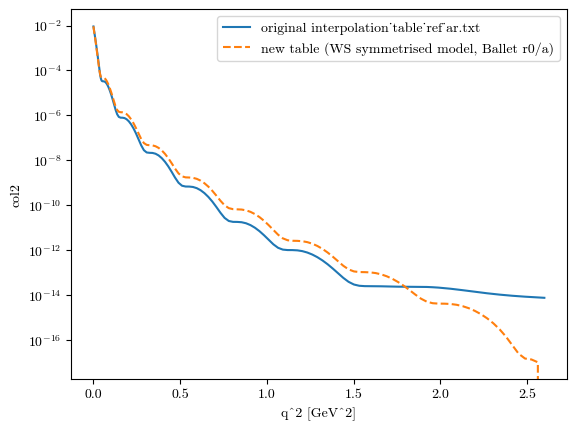

In [109]:
# From paper, old
r0_ballet = 1.126 * (40 ** (1/3)) # fm
a_ballet = 0.523 # fm

# From TridentSmite code:
r0_ballet = 1.07 * 40 **(1/3) # fm
a_ballet = 0.57 # fm


q2= interp_ar[:, 0]
q2[0] = 1e-18 # avoid divide by zero in F_Ar_WS_Symmetrised
table_ballet = F_to_table(lambda q2: F_Ar_WS_Symmetrised(q2, r0_ballet, a_ballet), q2)

plt.plot(interp_ar[:, 0], interp_ar[:, 1], label='original interpolation_table_ref_ar.txt')
plt.plot(table_ballet[:, 0], table_ballet[:, 1], '--', label='new table (WS symmetrised model, Ballet r0/a)')
plt.yscale('log')
plt.xlabel('q^2 [GeV^2]')
plt.ylabel('col2')
plt.legend()
plt.show()



np.savetxt('interpolation_table_ballet_ar.txt', table_ballet, delimiter=',', newline=',\n', fmt='%f')

# Fourier-Bessel & W-S parameter scan

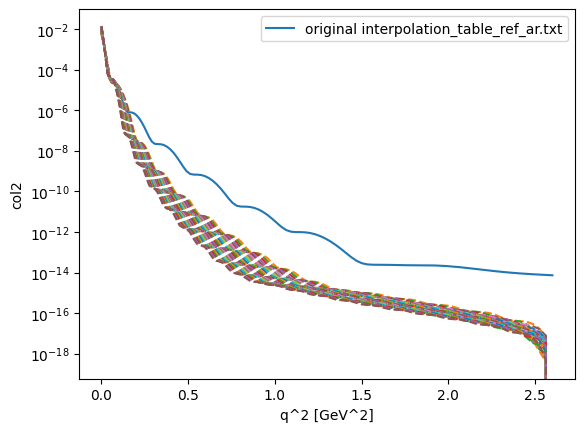

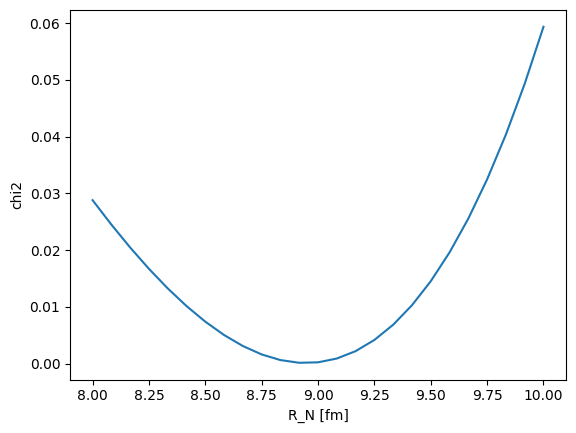

In [100]:
def chi2_func(OBS, EXP):
    return np.sum((OBS - EXP)**2 / (EXP + 1e-10))  # avoid div by zero

R_N_list = np.linspace(8.0, 10.0, 25)

target =  interp_ar[:, 1]
chi2_list = []
plt.plot(interp_ar[:, 0], target, label='original interpolation_table_ref_ar.txt')
for R_N in R_N_list:
    fb_table = F_to_table(vectorize_scalar_F(lambda q2: F_Ar_FourierBessel(q2, Norm=norm_fb, R_N_fm=R_N)), interp_ar[:, 0])
    plt.plot(fb_table[:, 0], fb_table[:, 1], '--')
    chi2 = chi2_func(fb_table[:, 1], target)
    chi2_list.append(chi2)
plt.yscale('log')
plt.xlabel('q^2 [GeV^2]')
plt.ylabel('col2')
plt.legend()
plt.show()

plt.plot(R_N_list, chi2_list)
plt.xlabel('R_N [fm]')
plt.ylabel('chi2')
plt.show()

Minimum chi2 = 0.000 at r0 = 3.442 fm, sigma = 0.613 fm


/tmp/ipykernel_3526800/4189908491.py:9: RuntimeWarning: divide by zero encountered in reciprocal
  F2 = np.pi * a * (np.tanh(np.pi * a * Q))**-1 * np.sin(Q * r0) - r0 * np.cos(Q * r0)
/tmp/ipykernel_3526800/4189908491.py:9: RuntimeWarning: invalid value encountered in multiply
  F2 = np.pi * a * (np.tanh(np.pi * a * Q))**-1 * np.sin(Q * r0) - r0 * np.cos(Q * r0)


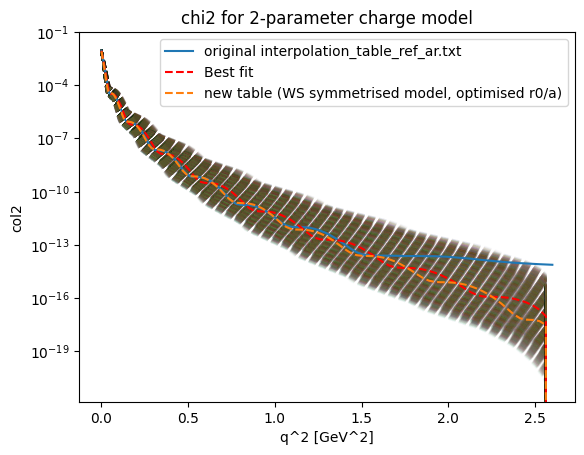

Text(0.5, 1.0, 'chi2 for 2-parameter charge model')

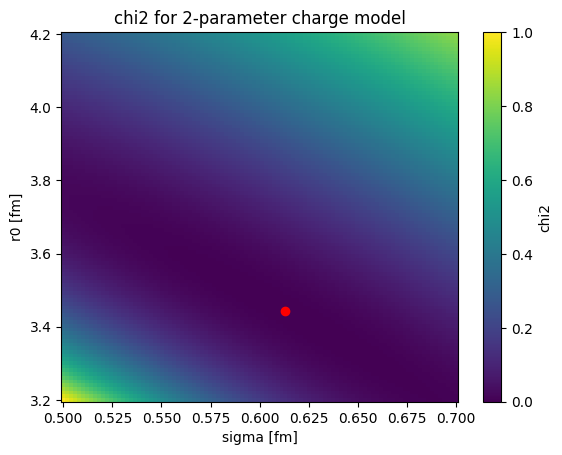

In [64]:
r0_list = np.linspace(3.2, 4.2, 100)
sigma_list = np.linspace(0.5, 0.7, 100)

grid_chi2 = np.zeros((len(r0_list), len(sigma_list)))

for i, r0 in enumerate(r0_list):
    for j, sigma in enumerate(sigma_list):
        new_table = F_to_table(lambda q2: F_Ar_WS_Symmetrised(q2, r0, sigma), interp_ar[1:, 0])
        chi2 = chi2_func(new_table[:, 1], target[1:])
        grid_chi2[i, j] = chi2
        plt.plot(new_table[:, 0], new_table[:, 1], '--', alpha=0.01)

plt.plot(interp_ar[:, 0], target, label='original interpolation_table_ref_ar.txt')



argmin = np.unravel_index(np.argmin(grid_chi2), grid_chi2.shape)
print(f"Minimum chi2 = {grid_chi2[argmin]:.3f} at r0 = {r0_list[argmin[0]]:.3f} fm, sigma = {sigma_list[argmin[1]]:.3f} fm")
best_table = F_to_table(lambda q2: F_Ar_WS_Symmetrised(q2, r0_list[argmin[0]], sigma_list[argmin[1]]), interp_ar[1:, 0])
plt.plot(best_table[:, 0], best_table[:, 1], '--', color='red', label='Best fit')

# Appears that a woods-saxon form factor with r0=3.69 fm and a=0.613 fm is a better fit to the original table 
# than the fourier-bessel it says they used in the paper.
interp_optimised_r0 = 3.69 # fm
interp_optimised_a = 0.613 # fm

new_table_optimised = F_to_table(lambda q2: F_Ar_WS_Symmetrised(q2, interp_optimised_r0, interp_optimised_a), interp_ar[:, 0])
plt.plot(new_table_optimised[:, 0], new_table_optimised[:, 1], '--', label='new table (WS symmetrised model, optimised r0/a)')

plt.yscale('log')
plt.xlabel('q^2 [GeV^2]')
plt.ylabel('col2')
plt.legend()
plt.title('chi2 for 2-parameter charge model')
plt.show()

plt.pcolormesh(sigma_list, r0_list, grid_chi2, shading='auto')
plt.scatter(sigma_list[argmin[1]], r0_list[argmin[0]], color='red', label='Minimum chi2')
plt.colorbar(label='chi2')
plt.xlabel('sigma [fm]')
plt.ylabel('r0 [fm]')
plt.title('chi2 for 2-parameter charge model')